In [ ]:
! pip install streamlit
 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8")

In [4]:
df = pd.read_csv(r"C:\Users\Danish\Downloads\Nassau Candy Distributor.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [6]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

## Data Cleaning

In [10]:
# Convert Dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

In [11]:
# Remove rows where sales or units are zero.
df = df[df['Sales'] > 0]
df = df[df['Units'] > 0]

In [12]:
df = df.dropna()

In [13]:
# Standardize Labels
df['Product Name'] = df['Product Name'].str.strip()
df['Division'] = df['Division'].str.strip()

## Feature Engineering (Create KPIs)

In [14]:
# Gross Margin %
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

In [15]:
# Profit per Unit
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

In [16]:
# Revenue Contribution
total_sales = df['Sales'].sum()
df['Revenue Contribution %'] = (df['Sales'] / total_sales) * 100

In [17]:
total_profit = df['Gross Profit'].sum()
df['Profit Contribution %'] = (df['Gross Profit'] / total_profit) * 100

## Sales Trend Over Time

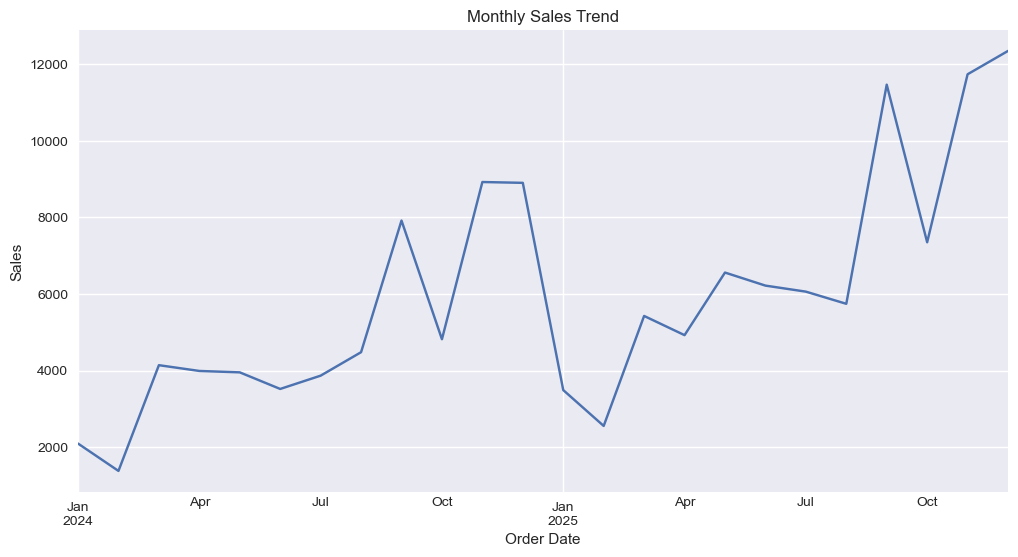

In [18]:
sales_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
sales_trend.plot(figsize=(12,6),title="Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

## Top 10 Products by Sales

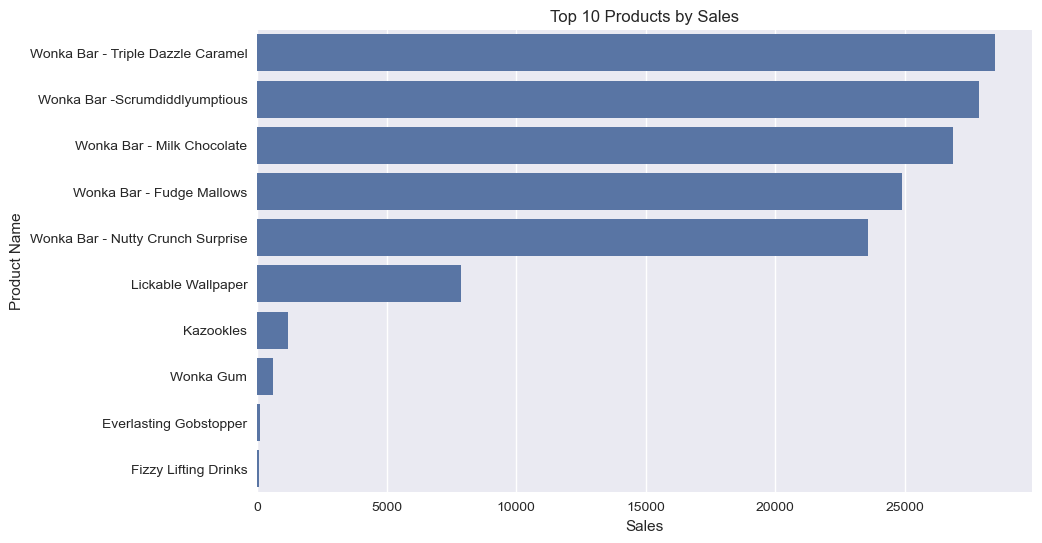

In [19]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values,y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

## Top 10 Products by Profit

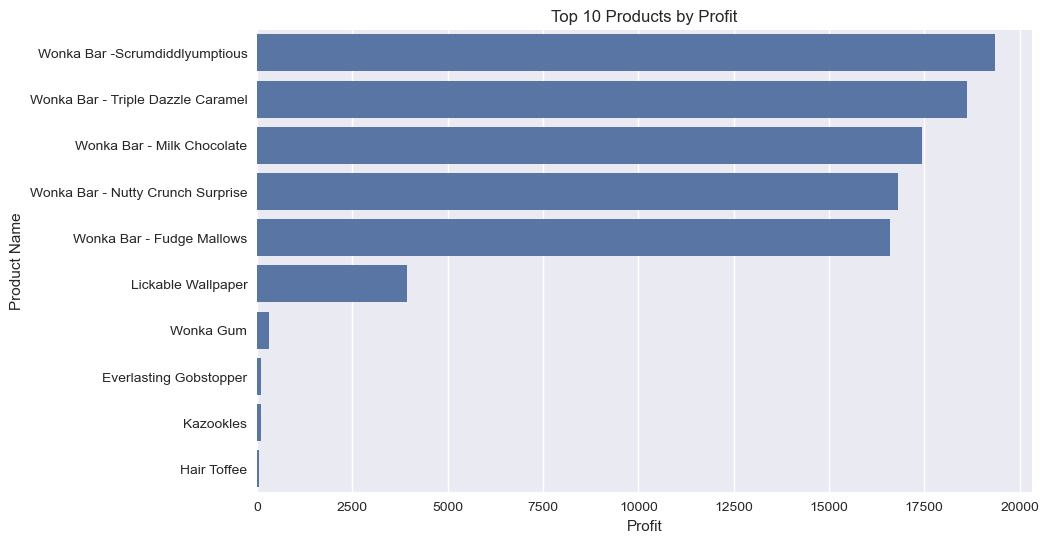

In [20]:
top_profit = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_profit.values,y=top_profit.index)
plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.show()

## Product-Level Profitability Analysis

In [21]:
product_analysis = df.groupby('Product Name').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Gross Profit','sum'),
    Total_Units=('Units','sum')
).reset_index()

product_analysis['Margin %'] = (product_analysis['Total_Profit'] / product_analysis['Total_Sales']) * 100
product_analysis['Profit per Unit'] = product_analysis['Total_Profit'] / product_analysis['Total_Units']

product_analysis.head()

,Product Name,Total_Sales,Total_Profit,Total_Units,Margin %,Profit per Unit
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25
2,Fun Dip,12.00,4.80,8,40.000000,0.60
3,Hair Toffee,76.50,59.50,17,77.777778,3.50
4,Kazookles,1205.75,92.75,371,7.692308,0.25


## Division-Level Performance Analysis

In [22]:
division_analysis = df.groupby('Division').agg(
    Sales=('Sales','sum'),
    Profit=('Gross Profit','sum'),
    Units=('Units','sum')
).reset_index()

division_analysis['Margin %'] = (division_analysis['Profit'] / division_analysis['Sales']) * 100

division_analysis

,Division,Sales,Profit,Units,Margin %
0,Chocolate,131692.90,88824.62,37275,67.448298
1,Other,9663.25,4333.45,1242,44.844643
2,Sugar,427.48,284.73,137,66.606625


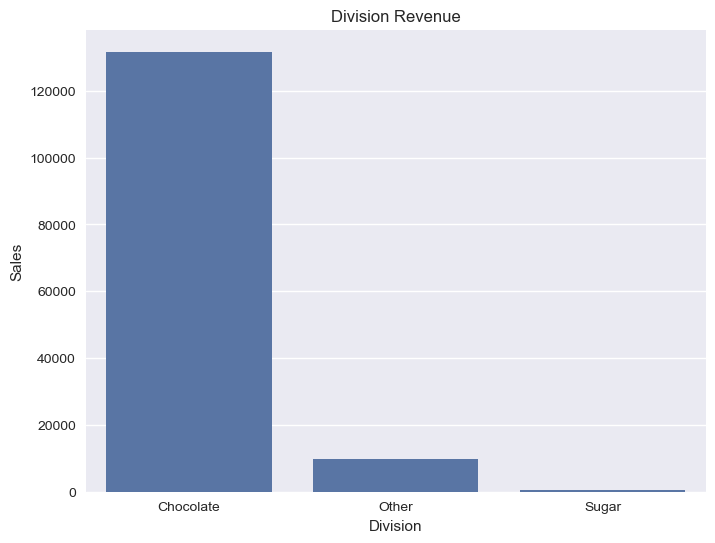

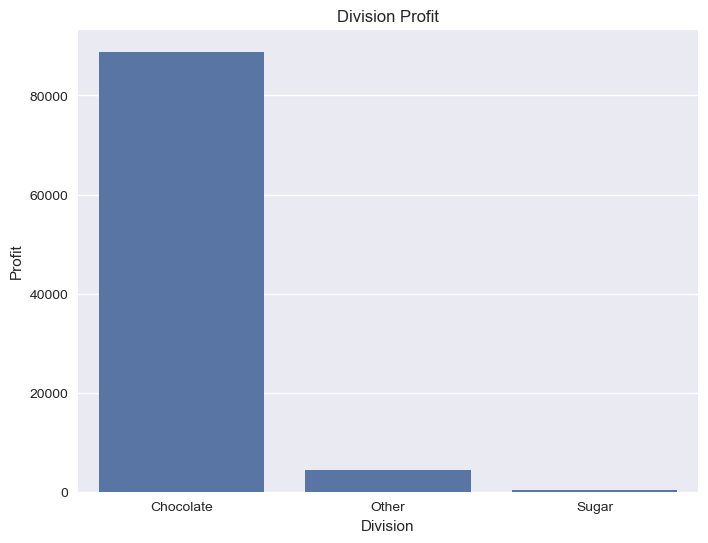

In [23]:
# Division Revenue vs Profit

plt.figure(figsize=(8,6))
sns.barplot(data=division_analysis,x='Division',y='Sales')
plt.title("Division Revenue")
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(data=division_analysis,x='Division',y='Profit')
plt.title("Division Profit")
plt.show()

## Margin Distribution

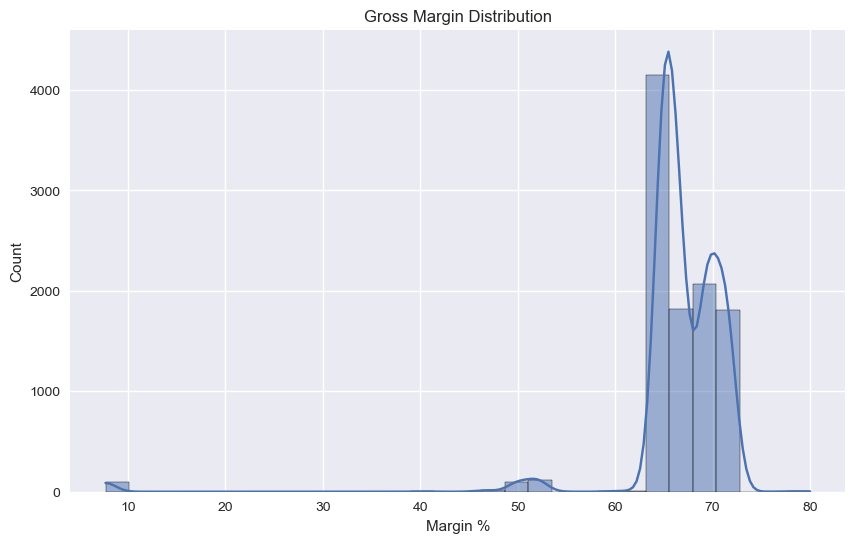

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(df['Gross Margin %'],bins=30,kde=True)

plt.title("Gross Margin Distribution")
plt.xlabel("Margin %")
plt.show()

## Cost vs Sales Analysis

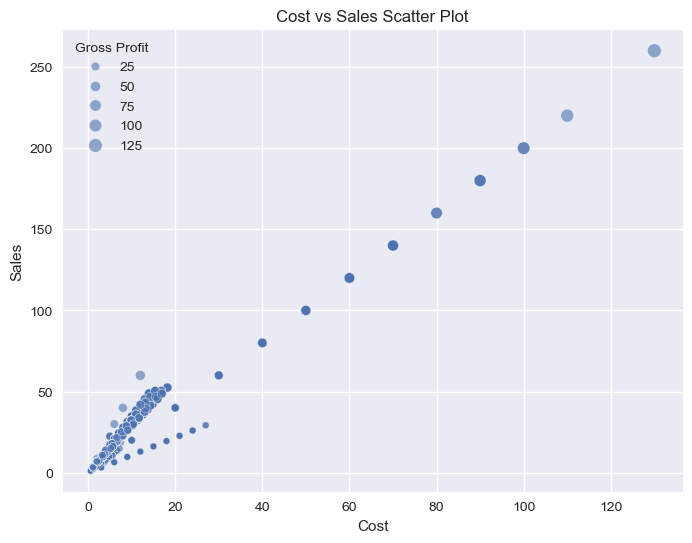

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Cost'],
    y=df['Sales'],
    size=df['Gross Profit'],
    alpha=0.6
)

plt.title("Cost vs Sales Scatter Plot")
plt.show()

## Pareto Analysis (Profit Concentration)

In [26]:
pareto = product_analysis.sort_values(by='Total_Profit',ascending=False)

pareto['Cumulative Profit'] = pareto['Total_Profit'].cumsum()

pareto['Cumulative %'] = pareto['Cumulative Profit'] / pareto['Total_Profit'].sum() * 100

C:\Users\Danish\AppData\Local\Temp\ipykernel_1960\3505622042.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pareto['Product Name'],rotation=90)


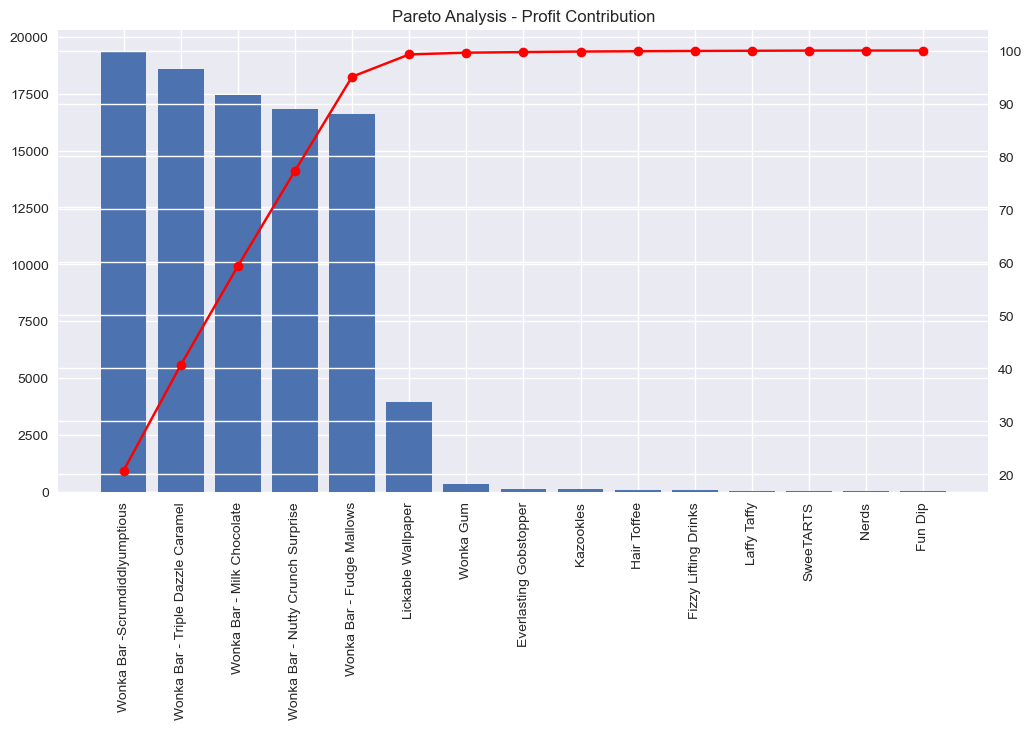

In [27]:
fig, ax = plt.subplots(figsize=(12,6))

ax.bar(pareto['Product Name'],pareto['Total_Profit'])

ax2 = ax.twinx()

ax2.plot(pareto['Product Name'],pareto['Cumulative %'],color='red',marker='o')

ax.set_xticklabels(pareto['Product Name'],rotation=90)

ax.set_title("Pareto Analysis - Profit Contribution")

plt.show()

## Regional Sales Analysis

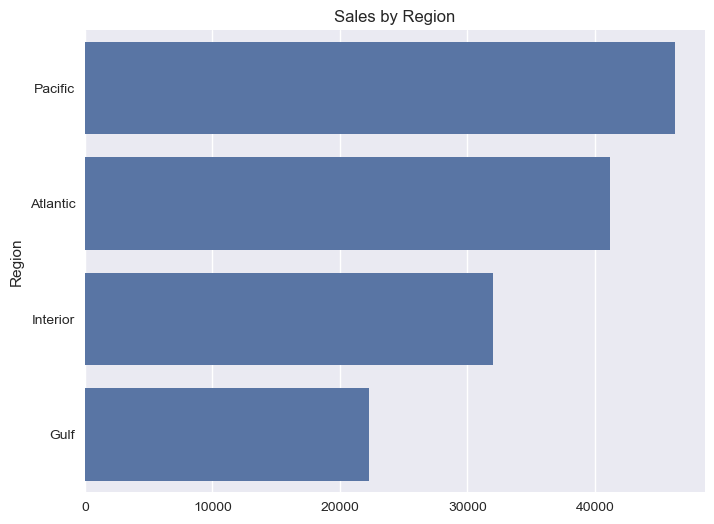

In [28]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=region_sales.values,y=region_sales.index)

plt.title("Sales by Region")
plt.show()

## Shipping Time Analysis

In [29]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [30]:
ship_analysis = df.groupby('Ship Mode')['Shipping Days'].mean()
ship_analysis

Ship Mode
First Class       1338.275840
Same Day          1333.442413
Second Class      1323.845376
Standard Class    1314.334641
Name: Shipping Days, dtype: float64

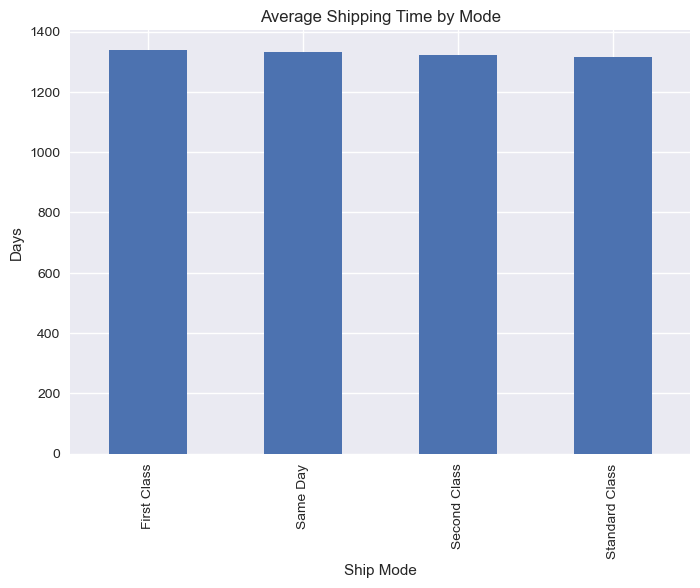

In [31]:
ship_analysis.plot(kind='bar',title="Average Shipping Time by Mode")
plt.ylabel("Days")
plt.show()

## Identify Low Margin Products

In [32]:
low_margin = product_analysis.sort_values(by='Margin %').head(10)
low_margin

,Product Name,Total_Sales,Total_Profit,Total_Units,Margin %,Profit per Unit
4,Kazookles,1205.75,92.75,371,7.692308,0.25
2,Fun Dip,12.00,4.80,8,40.000000,0.60
7,Nerds,15.00,7.00,10,46.666667,0.70
8,SweeTARTS,61.50,28.70,41,46.666667,0.70
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00
14,Wonka Gum,597.50,310.70,478,52.000000,0.65
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45


## Identify High Margin Products

In [33]:
high_margin = product_analysis.sort_values(by='Margin %',ascending=False).head(10)

high_margin

,Product Name,Total_Sales,Total_Profit,Total_Units,Margin %,Profit per Unit
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
3,Hair Toffee,76.50,59.50,17,77.777778,3.50
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25
14,Wonka Gum,597.50,310.70,478,52.000000,0.65


In [34]:
product_analysis.to_csv("product_profitability_analysis.csv",index=False)

division_analysis.to_csv("division_performance.csv",index=False)